In [1]:
#Import Libraries

import os
import glob
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

from torchvision import models, transforms

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
torch.manual_seed(42); np.random.seed(42)

In [2]:
#checking if dataset is connected
!ls /kaggle/input


datasets


In [3]:
#LOAD THE HAM1000 DATASET
# Dataset contains information such as image ID, diagnosis,age,sex,lesion ID

# Find the metadata file
csv_path = glob.glob(
    "/kaggle/input/**/HAM10000_metadata.csv",
    recursive=True
)[0]

# Get dataset folder
root = os.path.dirname(csv_path)

print("Dataset folder:")
print(root)

# Load metadata
df = pd.read_csv(csv_path)

print("\nDataset shape:")
print(df.shape)

df.head()

Dataset folder:
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000

Dataset shape:
(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:

#CONNECT EACH IMAGE TO ITS METADATA

# Find all JPG images in the dataset
paths = {
    os.path.basename(p)[:-4]: p
    for p in glob.glob(
        f"{root}/**/*.jpg",
        recursive=True
    )
}

# Match image IDs with image paths
df["path"] = df["image_id"].map(paths)

# Convert diagnosis labels into numbers
df["label"] = df["dx"].astype("category").cat.codes

# Store class names
classes = list(
    df["dx"].astype("category").cat.categories
)

print("Classes:")
print(classes)

print("\nMissing image paths:")
print(df["path"].isna().sum())

print("\nNumber of classes:")
print(len(classes))

Classes:
['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Missing image paths:
0

Number of classes:
7


In [5]:
# CHECK AND CLEAN THE DATASET

print("Missing values:")
print(df.isna().sum())

print("\nDuplicate image IDs:")
print(df["image_id"].duplicated().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nMissing image paths:")
print(df["path"].isna().sum())

print("\nClass distribution:")
print(df["dx"].value_counts())

Missing values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
label            0
dtype: int64

Duplicate image IDs:
0

Duplicate rows:
0

Missing image paths:
0

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [6]:
#CLEAN THE DATA

# Keep only images with known sex
df = df[df["sex"].isin(["male", "female"])]

# Remove records with missing age
df = df.dropna(subset=["age"])

# Remove records without an image path
df = df.dropna(subset=["path"])

# Reset dataframe index
df = df.reset_index(drop=True)

print("Dataset after cleaning:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df.isna().sum())

Dataset after cleaning:
(9948, 9)

Missing values after cleaning:
lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
path            0
label           0
dtype: int64


dx
nv       6650
mel      1111
bkl      1089
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


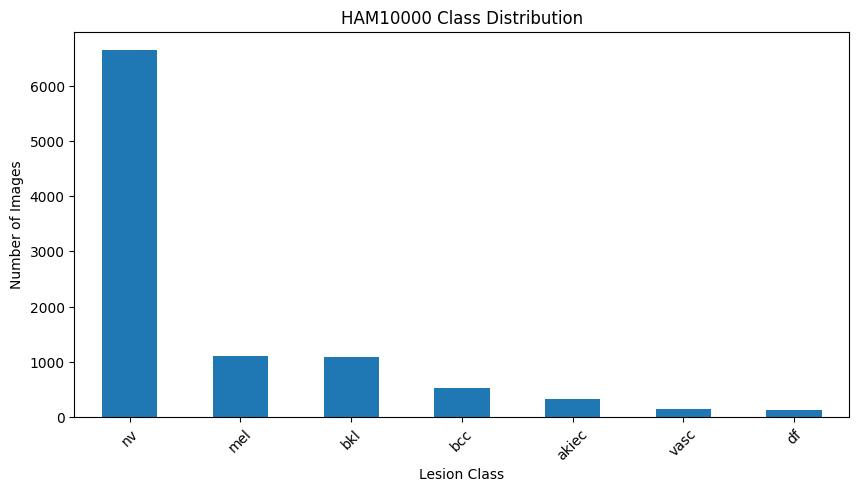

In [7]:
#EXPLORE CLASS DISTRIBUTION
#noticed that the class are highly imbalanced

class_counts = df["dx"].value_counts()

print(class_counts)

plt.figure(figsize=(10, 5))

class_counts.plot(kind="bar")

plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

In [8]:
#CREATE AGE GROUPS
#to investigate if performance differs across age groups

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 60, 120],
    labels=["<30", "30-60", "60+"]
)

print(
    pd.crosstab(
        df["dx"],
        df["age_group"]
    )
)

age_group  <30  30-60  60+
dx                        
akiec        1    123  203
bcc          8    141  365
bkl          7    442  635
df           6     75   34
mel         57    503  551
nv         982   4674  966
vasc        23     70   45


In [9]:
#SPLIT THE DATA
#making sure same lesion images dont appear in both training and testing

def create_group_split(data, n_splits):
    
    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )
    
    train_idx, test_idx = next(
        sgkf.split(
            data,
            data["label"],
            groups=data["lesion_id"]
        )
    )
    
    train_data = data.iloc[train_idx].reset_index(drop=True)
    test_data = data.iloc[test_idx].reset_index(drop=True)
    
    return train_data, test_data


# First split
trainval, test = create_group_split(df, 5)

# Second split
train, val = create_group_split(trainval, 8)

print("Training images:", len(train))
print("Validation images:", len(val))
print("Testing images:", len(test))

Training images: 6968
Validation images: 987
Testing images: 1993


In [10]:
#CHECK FOR DATA LEAKAGE

train_lesions = set(train["lesion_id"])
val_lesions = set(val["lesion_id"])
test_lesions = set(test["lesion_id"])

print(
    "Train/Test overlap:",
    len(train_lesions & test_lesions)
)

print(
    "Train/Validation overlap:",
    len(train_lesions & val_lesions)
)

print(
    "Validation/Test overlap:",
    len(val_lesions & test_lesions)
)

Train/Test overlap: 0
Train/Validation overlap: 0
Validation/Test overlap: 0


In [11]:
#SET UP PREPROCESSING

# Select GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# ImageNet normalization
normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

# Training preprocessing + augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    normalization
])

# Validation and test preprocessing
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalization
])

Using device: cuda


In [12]:
#CREATE THE DATASET CLASS

class SkinLesionDataset(Dataset):
    
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        
        row = self.dataframe.iloc[index]
        
        image = Image.open(
            row["path"]
        ).convert("RGB")
        
        image = self.transform(image)
        
        label = int(row["label"])
        
        return image, label

In [13]:
#CREATE DATALOADERS

train_dataset = SkinLesionDataset(
    train,
    train_transform
)

val_dataset = SkinLesionDataset(
    val,
    eval_transform
)

test_dataset = SkinLesionDataset(
    test,
    eval_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)


print("DataLoaders created.")

DataLoaders created.


In [14]:
#CALCULATE CLASS WEIGHTS
#helps model pay attention to minority classes

class_counts = (
    train["label"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    class_counts.sum()
    / (len(classes) * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")
print(class_weights)

Class weights:
tensor([ 4.0301,  2.9538,  1.2427, 12.2892,  1.3029,  0.2153,  8.7318],
       device='cuda:0')


In [15]:
#DEFINING THE MODELS
#our model selection stage
#comparing : 1. ResNet18, 2.ResNet50 , 3. EfficientNet-B0


NUM_CLASSES = 7


def build_model(model_name):

    if model_name == "ResNet18":
        
        model = models.resnet18(
            weights="IMAGENET1K_V1"
        )
        
        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    elif model_name == "ResNet50":
        
        model = models.resnet50(
            weights="IMAGENET1K_V2"
        )
        
        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    elif model_name == "EfficientNet-B0":
        
        model = models.efficientnet_b0(
            weights="IMAGENET1K_V1"
        )
        
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )


    else:
        raise ValueError(
            "Unknown model name"
        )


    return model.to(device)

In [16]:
#DEFINE THE TRAINING FUNCTION

def train_model(model, epochs=8):

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4
    )

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights
    )

    best_val_f1 = 0.0
    best_state = None

    history = []

    for epoch in range(epochs):

        # -------------------------
        # TRAINING
        # -------------------------
        
        model.train()

        total_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = loss_function(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()


        # -------------------------
        # VALIDATION
        # -------------------------
        
        model.eval()

        predictions = []
        targets = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                outputs = model(images)

                predicted = (
                    outputs
                    .argmax(1)
                    .cpu()
                    .numpy()
                )

                predictions.extend(
                    predicted
                )

                targets.extend(
                    labels.numpy()
                )


        val_f1 = f1_score(
            targets,
            predictions,
            average="macro",
            zero_division=0
        )


        average_loss = (
            total_loss / len(train_loader)
        )


        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"| Loss: {average_loss:.4f} "
            f"| Validation Macro-F1: {val_f1:.4f}"
        )


        history.append({
            "epoch": epoch + 1,
            "loss": average_loss,
            "val_macro_f1": val_f1
        })


        # Save best validation model
        if val_f1 > best_val_f1:

            best_val_f1 = val_f1

            best_state = {
                key: value.cpu().clone()
                for key, value
                in model.state_dict().items()
            }


    # Load best model
    model.load_state_dict(
        best_state
    )

    return model, best_val_f1, history

In [17]:
#TRAIN ResNet18

print("Training ResNet18...")

resnet18 = build_model("ResNet18")

resnet18, resnet18_f1, history18 = train_model(
    resnet18,
    epochs=8
)

print(
    "\nBest ResNet18 Validation Macro-F1:",
    round(resnet18_f1, 4)
)

Training ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


Epoch 1/8 | Loss: 1.2183 | Validation Macro-F1: 0.4285
Epoch 2/8 | Loss: 0.8583 | Validation Macro-F1: 0.3352
Epoch 3/8 | Loss: 0.7668 | Validation Macro-F1: 0.5327
Epoch 4/8 | Loss: 0.6828 | Validation Macro-F1: 0.5265
Epoch 5/8 | Loss: 0.5873 | Validation Macro-F1: 0.4961
Epoch 6/8 | Loss: 0.5171 | Validation Macro-F1: 0.5912
Epoch 7/8 | Loss: 0.5409 | Validation Macro-F1: 0.5249
Epoch 8/8 | Loss: 0.5154 | Validation Macro-F1: 0.5583

Best ResNet18 Validation Macro-F1: 0.5912


In [18]:
#TRAIN ResNet50

print("Training ResNet50...")

resnet50 = build_model("ResNet50")

resnet50, resnet50_f1, history50 = train_model(
    resnet50,
    epochs=8
)

print(
    "\nBest ResNet50 Validation Macro-F1:",
    round(resnet50_f1, 4)
)

Training ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Epoch 1/8 | Loss: 1.2599 | Validation Macro-F1: 0.4765
Epoch 2/8 | Loss: 0.8142 | Validation Macro-F1: 0.4992
Epoch 3/8 | Loss: 0.6060 | Validation Macro-F1: 0.5372
Epoch 4/8 | Loss: 0.6032 | Validation Macro-F1: 0.5692
Epoch 5/8 | Loss: 0.4635 | Validation Macro-F1: 0.5909
Epoch 6/8 | Loss: 0.4238 | Validation Macro-F1: 0.6017
Epoch 7/8 | Loss: 0.4130 | Validation Macro-F1: 0.6329
Epoch 8/8 | Loss: 0.4158 | Validation Macro-F1: 0.6139

Best ResNet50 Validation Macro-F1: 0.6329


In [19]:
#TRAIN EfficientNet-B0

print("Training EfficientNet-B0...")

efficientnet = build_model(
    "EfficientNet-B0"
)

efficientnet, efficientnet_f1, history_eff = train_model(
    efficientnet,
    epochs=8
)

print(
    "\nBest EfficientNet-B0 Validation Macro-F1:",
    round(efficientnet_f1, 4)
)

Training EfficientNet-B0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 


Epoch 1/8 | Loss: 1.1887 | Validation Macro-F1: 0.5100
Epoch 2/8 | Loss: 0.7123 | Validation Macro-F1: 0.5575
Epoch 3/8 | Loss: 0.5619 | Validation Macro-F1: 0.6387
Epoch 4/8 | Loss: 0.4397 | Validation Macro-F1: 0.6841
Epoch 5/8 | Loss: 0.3744 | Validation Macro-F1: 0.6862
Epoch 6/8 | Loss: 0.3369 | Validation Macro-F1: 0.6078
Epoch 7/8 | Loss: 0.2614 | Validation Macro-F1: 0.6931
Epoch 8/8 | Loss: 0.2616 | Validation Macro-F1: 0.7147

Best EfficientNet-B0 Validation Macro-F1: 0.7147


In [20]:
#COMPARE THE MODELS
#important model selection cell

model_results = pd.DataFrame({
    "Model": [
        "ResNet18",
        "ResNet50",
        "EfficientNet-B0"
    ],
    
    "Validation Macro-F1": [
        resnet18_f1,
        resnet50_f1,
        efficientnet_f1
    ]
})

model_results = model_results.sort_values(
    by="Validation Macro-F1",
    ascending=False
).reset_index(drop=True)

print(model_results.round(4))

             Model  Validation Macro-F1
0  EfficientNet-B0               0.7147
1         ResNet50               0.6329
2         ResNet18               0.5912


In [21]:
#SELECT THE BEST MODEL

best_model_name = model_results.iloc[0]["Model"]

print(
    "Selected model:",
    best_model_name
)

Selected model: EfficientNet-B0


In [22]:
#PUT THE MODELS INTO A DICTIONARY

trained_models = {
    "ResNet18": resnet18,
    "ResNet50": resnet50,
    "EfficientNet-B0": efficientnet
}

best_model = trained_models[
    best_model_name
]

print(
    "Final model:",
    best_model_name
)

Final model: EfficientNet-B0


In [23]:
#FINAL EVALUATION FUNCTION

def evaluate_model(model, dataloader):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            predicted = (
                outputs
                .argmax(1)
                .cpu()
                .numpy()
            )

            predictions.extend(
                predicted
            )

            targets.extend(
                labels.numpy()
            )


    accuracy = accuracy_score(
        targets,
        predictions
    )

    macro_recall = recall_score(
        targets,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        targets,
        predictions,
        average="macro",
        zero_division=0
    )


    return (
        np.array(targets),
        np.array(predictions),
        accuracy,
        macro_recall,
        macro_f1
    )

In [24]:
#EVALUATE THE SELECTED MODEL

test_targets, test_predictions, test_accuracy, test_macro_recall, test_macro_f1 = evaluate_model(
    best_model,
    test_loader
)

print("FINAL TEST RESULTS")
print("------------------")

print(
    "Accuracy:",
    round(test_accuracy, 4)
)

print(
    "Macro Recall:",
    round(test_macro_recall, 4)
)

print(
    "Macro F1:",
    round(test_macro_f1, 4)
)

FINAL TEST RESULTS
------------------
Accuracy: 0.7858
Macro Recall: 0.7212
Macro F1: 0.6545


In [25]:
#CLASSIFICATION REPORT

print(
    classification_report(
        test_targets,
        test_predictions,
        target_names=classes,
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       akiec      0.500     0.732     0.594        56
         bcc      0.635     0.885     0.740       122
         bkl      0.589     0.650     0.618       183
          df      0.500     0.667     0.571        24
         mel      0.441     0.586     0.503       215
          nv      0.953     0.832     0.889      1370
        vasc      0.640     0.696     0.667        23

    accuracy                          0.786      1993
   macro avg      0.608     0.721     0.655      1993
weighted avg      0.823     0.786     0.798      1993



Confusion Matrix:
[[  41    3    6    0    6    0    0]
 [   6  108    2    1    1    2    2]
 [  10   14  119    0   22   17    1]
 [   3    1    1   16    2    1    0]
 [  14    8   28    3  126   36    0]
 [   7   34   46   12  125 1140    6]
 [   1    2    0    0    4    0   16]]


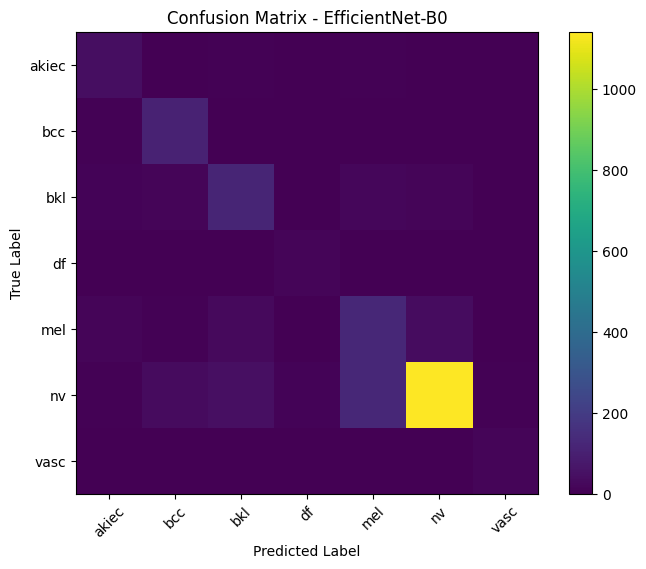

In [26]:
#CONFUSION MATRIX

cm = confusion_matrix(
    test_targets,
    test_predictions
)

print("Confusion Matrix:")
print(cm)


plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()

plt.show()

In [27]:
#STORE PREDICTIONS IN THE TEST DATAFRAME

test_results = test.copy()

test_results["predicted_label"] = (
    test_predictions
)

test_results["predicted_class"] = [
    classes[p]
    for p in test_predictions
]

test_results.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label,age_group,predicted_label,predicted_class
0,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,60+,1,bcc
1,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,60+,1,bcc
2,HAM_0001949,ISIC_0025767,bkl,histo,70.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,60+,2,bkl
3,HAM_0001949,ISIC_0032417,bkl,histo,70.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,60+,2,bkl
4,HAM_0002299,ISIC_0025819,bkl,histo,75.0,female,face,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,60+,2,bkl


In [28]:
#COMPARE PERFORMANCE BY SEX

sex_results = []

for group, data in test_results.groupby("sex"):

    accuracy = (
        data["label"]
        == data["predicted_label"]
    ).mean()

    macro_f1 = f1_score(
        data["label"],
        data["predicted_label"],
        average="macro",
        labels=range(7),
        zero_division=0
    )

    macro_recall = recall_score(
        data["label"],
        data["predicted_label"],
        average="macro",
        labels=np.unique(data["label"]),
        zero_division=0
    )

    sex_results.append({
        "Sex": group,
        "Number of Images": len(data),
        "Accuracy": accuracy,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    })


sex_results = pd.DataFrame(
    sex_results
)

print(
    sex_results.round(3)
)

      Sex  Number of Images  Accuracy  Macro Recall  Macro F1
0  female               932     0.793         0.762     0.634
1    male              1061     0.779         0.715     0.672


In [29]:
#COMPARE PERFORMANCE BY AGE GROUP


age_results = []

for group, data in test_results.groupby(
    "age_group",
    observed=True
):

    accuracy = (
        data["label"]
        == data["predicted_label"]
    ).mean()

    macro_f1 = f1_score(
        data["label"],
        data["predicted_label"],
        average="macro",
        labels=np.unique(data["label"]),
        zero_division=0
    )

    macro_recall = recall_score(
        data["label"],
        data["predicted_label"],
        average="macro",
        labels=range(7),
        zero_division=0
    )

    age_results.append({
        "Age Group": str(group),
        "Number of Images": len(data),
        "Accuracy": accuracy,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1
    })


age_results = pd.DataFrame(
    age_results
)

print(
    age_results.round(3)
)

  Age Group  Number of Images  Accuracy  Macro Recall  Macro F1
0       <30               226     0.743         0.532     0.559
1     30-60              1200     0.822         0.674     0.598
2       60+               561     0.724         0.803     0.734


In [30]:
#MELANOMA SPECIFIC PERFORMANCE

melanoma_index = classes.index("mel")

melanoma_true = (
    test_targets == melanoma_index
)

melanoma_predicted = (
    test_predictions == melanoma_index
)

melanoma_recall = recall_score(
    melanoma_true,
    melanoma_predicted,
    zero_division=0
)

print(
    "Melanoma Recall:",
    round(melanoma_recall, 4)
)

Melanoma Recall: 0.586


In [31]:
rng = np.random.default_rng(42)
mel = classes.index("mel")
test_results["is_mel"] = test_results["label"] == mel
test_results["pred_mel"] = test_results["predicted_label"] == mel

def mel_recall_ci(d, n_boot=2000):
    m = d[d.is_mel]
    if len(m) == 0:
        return 0, np.nan, np.nan, np.nan
    # resample by lesion, because images of one lesion are not independent
    per = m.groupby("lesion_id")["pred_mel"].agg(["sum", "count"]).to_numpy()
    idx = rng.integers(0, len(per), (n_boot, len(per)))
    boots = per[idx, 0].sum(1) / per[idx, 1].sum(1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return len(m), per[:, 0].sum() / per[:, 1].sum(), lo, hi

In [32]:
from skimage.color import rgb2lab
from tqdm.auto import tqdm

def estimate_ita(path):
    img = Image.open(path)
    img.draft("RGB", (160, 120))                 # fast low-res decode
    img = img.convert("RGB").resize((160, 120))
    lab = rgb2lab(np.asarray(img) / 255.0)
    L, b = lab[..., 0], lab[..., 2]

    h, w = L.shape
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt(((xx - w / 2) / (w / 2)) ** 2 + ((yy - h / 2) / (h / 2)) ** 2)

    mask = (r > 0.75) & (L > 30) & (L < 95)      # outer ring, no vignette or glare
    if mask.sum() < 200:
        mask = (L > 30) & (L < 95)
    if mask.sum() == 0:
        return np.nan

    L_med, b_med = np.median(L[mask]), np.median(b[mask])
    if b_med <= 0:
        return np.nan
    return float(np.degrees(np.arctan((L_med - 50) / b_med)))

df["ita"] = [estimate_ita(p) for p in tqdm(df["path"])]
print(df["ita"].describe())

  0%|          | 0/9948 [00:00<?, ?it/s]

count    6514.000000
mean       63.356921
std        19.766312
min       -86.935840
25%        52.300900
50%        67.201574
75%        78.313466
max        89.993745
Name: ita, dtype: float64


In [33]:
bins = [-90, -30, 10, 28, 41, 55, 90]
labels = ["dark", "brown", "tan", "intermediate", "light", "very light"]
df["ita_type"] = pd.cut(df["ita"], bins=bins, labels=labels)
print(df["ita_type"].value_counts(dropna=False).reindex(labels + [np.nan]))

ita_type
dark              10
brown             83
tan              264
intermediate     492
light           1024
very light      4641
NaN             3434
Name: count, dtype: int64


In [34]:
test_results = test_results.drop(columns=["ita"], errors="ignore").merge(
    df[["image_id", "ita"]], on="image_id", how="left"
)

# Absolute groups (standard ITA cut-offs)
test_results["tone_absolute"] = pd.cut(
    test_results["ita"], bins=[-90, 28, 41, 55, 90],
    labels=["tan or darker (<=28)", "intermediate (28-41)",
            "light (41-55)", "very light (>55)"]
)

# Relative groups (equal-sized thirds, more stable statistics)
test_results["tone_tertile"] = pd.qcut(
    test_results["ita"], 3,
    labels=["darkest third", "middle third", "lightest third"]
)

print(test_results["tone_absolute"].value_counts(dropna=False))

tone_absolute
very light (>55)        922
NaN                     710
light (41-55)           196
intermediate (28-41)    104
tan or darker (<=28)     61
Name: count, dtype: int64


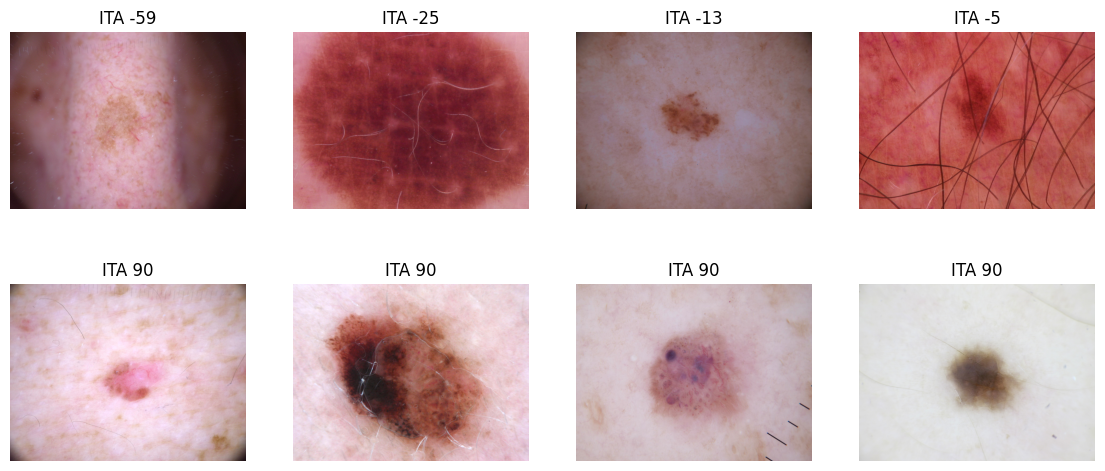

In [35]:
srt = test_results.dropna(subset=["ita"]).sort_values("ita")
pick = pd.concat([srt.head(4), srt.tail(4)])

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (_, row) in zip(axes.ravel(), pick.iterrows()):
    ax.imshow(Image.open(row["path"]))
    ax.set_title(f"ITA {row['ita']:.0f}")
    ax.axis("off")
plt.show()

In [36]:
def group_report(col):
    rows = []
    for g, d in test_results.groupby(col, observed=True):
        n_mel, r, lo, hi = mel_recall_ci(d)
        rows.append({
            "Group": str(g),
            "Images": len(d),
            "Accuracy": (d.label == d.predicted_label).mean(),
            "Macro recall": recall_score(d.label, d.predicted_label, average="macro",
                                         labels=np.unique(d.label), zero_division=0),
            "Melanoma n": n_mel,
            "Mel recall": r, "CI low": lo, "CI high": hi,
        })
    return pd.DataFrame(rows).round(3)

print(group_report("tone_absolute"))
print(group_report("tone_tertile"))

                  Group  Images  Accuracy  Macro recall  Melanoma n  \
0  tan or darker (<=28)      61     0.885         0.813           6   
1  intermediate (28-41)     104     0.913         0.828           5   
2         light (41-55)     196     0.908         0.717           9   
3      very light (>55)     922     0.824         0.677          80   

   Mel recall  CI low  CI high  
0       0.833   0.500    1.000  
1       0.600   0.200    1.000  
2       0.556   0.222    0.889  
3       0.562   0.438    0.688  
            Group  Images  Accuracy  Macro recall  Melanoma n  Mel recall  \
0   darkest third     428     0.907         0.789          23       0.609   
1    middle third     427     0.867         0.749          26       0.462   
2  lightest third     428     0.769         0.680          51       0.627   

   CI low  CI high  
0   0.409    0.800  
1   0.259    0.696  
2   0.483    0.784  


In [37]:
#SAVE THE FINAL MODEL

torch.save(
    best_model.state_dict(),
    "best_skin_lesion_model.pth"
)

print(
    "Final model saved as:",
    "best_skin_lesion_model.pth"
)

Final model saved as: best_skin_lesion_model.pth
